# Day 5: Waste Detection Web Demo using Gradio

I have deployed my custom YOLO11 model as an interactive web application.

**Features:**
- Upload any image
- Real-time waste detection
- Clear bounding boxes with labels

In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.9 MB/s eta 0:00:00


In [2]:
!pip install roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.9 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import torch
from roboflow import Roboflow
import gradio as gr

print("✅ Setup complete!")
print("Setup Complete!")
print("GPU Available:", torch.cuda.is_available())


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Setup complete!
Setup Complete!
GPU Available: True


In [4]:
!from roboflow import Roboflow
import os
from getpass import getpass

# Secure way to load API key
if 'ROBOFLOW_API_KEY' in os.environ:
    api_key = os.environ['ROBOFLOW_API_KEY']
else:
    api_key = getpass('Enter your Roboflow API Key: ')

rf = Roboflow(api_key=api_key)

project = rf.workspace("hayat-ahmedjara").project("waste-detection-u70wn-pmykf")
version = project.version(1)
dataset = version.download("yolov11")


/bin/bash: line 1: from: command not found
Enter your Roboflow API Key: ··········
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Waste-Detection-1 in yolov11:: 100%|██████████| 1001/1001 [00:00<00:00, 3344.40it/s]


In [5]:
# After downloading the dataset, run this:
print("Dataset Location:", dataset.location)

# Also print the full path of data.yaml
print("Data YAML Path:", f"{dataset.location}/data.yaml")

Dataset Location: /content/Waste-Detection-1
Data YAML Path: /content/Waste-Detection-1/data.yaml


## 2. Training the Custom Model

We will train YOLO11s on our waste detection dataset.

In [6]:


# Load pre-trained model
model = YOLO("yolo11s.pt")

# Start Training
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    name="waste_detection_model",
    patience=15,             # Stop early if no improvement
    augment=True             # Data Augmentation means artificially creating more variations of your training
                             # images so the model becomes stronger and smarter.

)

print("✅ Training Completed!")

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Waste-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=waste_detection_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

## 3. Testing the Trained Model

In [7]:
# Cell 2 - Load your best model
best_model = YOLO("/content/runs/detect/waste_detection_model/weights/best.pt")

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [9]:
# Cell 3 - Define the prediction function
def detect_waste(image):
    results = best_model.predict(image, conf=0.25, verbose=False)
    annotated_image = results[0].plot()   # Draw boxes and labels
    return annotated_image

# Create Gradio Interface
interface = gr.Interface(
    fn=detect_waste,
    inputs=gr.Image(type="pil", label="Upload an Image"),
    outputs=gr.Image(type="pil", label="Detection Result"),
    title="♻️ Waste Detection Model",
    description="Upload an image to detect different types of waste (plastic, bottles, garbage, etc.)",

    allow_flagging="never"
)

# Launch the app
interface.launch(share=True)   # share=True gives you a public link

The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://51c786cc8c0d344a87.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


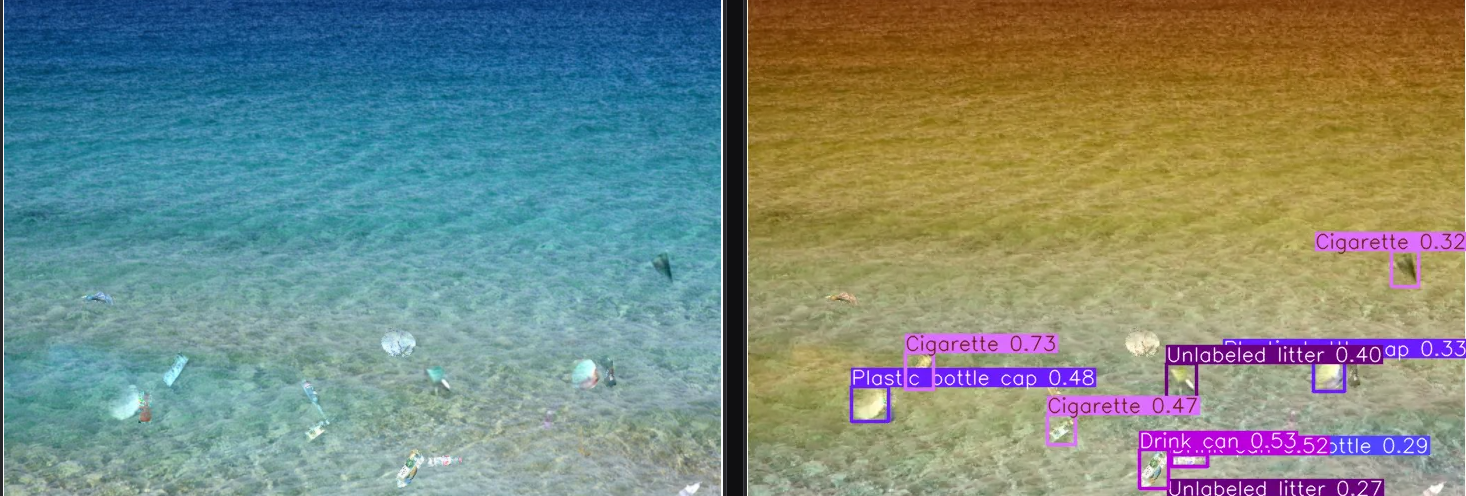

## 4. Testing the Model - Image Detection

I tested the trained Waste Detection model on several images to evaluate its performance.

### Test Results:

**Observations:**
- The model is able to detect waste objects with reasonable confidence.
- It performs better on images similar to the training dataset (beach waste, plastic bottles, garbage, etc.).
- Some false positives / missed detections are expected since the model was trained for only 30 epochs.



### Key Learnings from Testing:
- Confidence threshold (`conf=0.25`) works well as a balance.
- The model needs more training epochs and diverse data to improve accuracy.
- Real-world images (different lighting, angles) are challenging for the current model.

---

**Next Goal:** Improve the model and deploy it as a web application.